HW2 -MEGHAN KRIEG

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pandas.tseries.holiday import USFederalHolidayCalendar
from datetime import datetime

1. Find an interesting feature in the US Birth data set that we didn't find in class.  Be sure to describe clearly the feature you found, and include figures to back it up.

I will find the number of births per season. Assumption winter is 

In [2]:
birth_data = pd.read_csv("US_births_2000-2014_SSA.csv")

spring = birth_data[(birth_data["month"] >= 4) & (birth_data["month"] <= 6)]
fall = birth_data[(birth_data["month"] >= 10) & (birth_data["month"] <= 12)]
summer = birth_data[(birth_data["month"] >= 7) & (birth_data["month"] <= 9)]
winter = birth_data[(birth_data["month"] >= 1) & (birth_data["month"] <= 3)]



This should give me the number of births and counts per days that are only within their season. So the different colors will indicate the season and then the histogram will be read like the previous histograms. 

Text(0, 0.5, 'Counts')

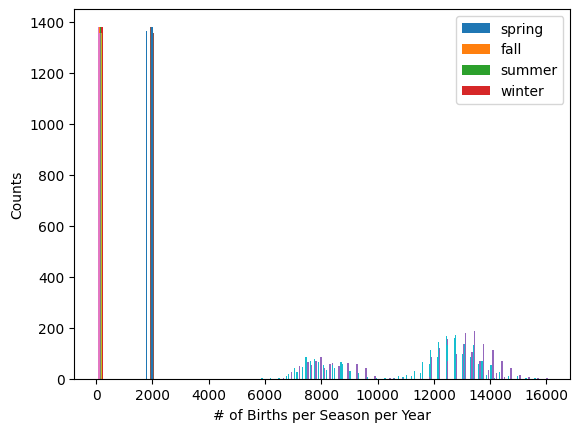

In [210]:
plt.hist(spring, bins = 50);
plt.hist(fall, bins = 50);
plt.hist(summer, bins = 50);
plt.hist(winter, bins = 50);
plt.legend(["spring",'fall','summer','winter'])
plt.xlabel('# of Births per Season per Year')
plt.ylabel('Counts')


If you want the number of babies per season, the group by function should do it?

In [4]:
num_spring = spring.groupby('year').sum()
num_fall = fall.groupby('year').sum()
num_winter = winter.groupby('year').sum()
num_summer = summer.groupby('year').sum()


Then I can get the number of babies per year by season

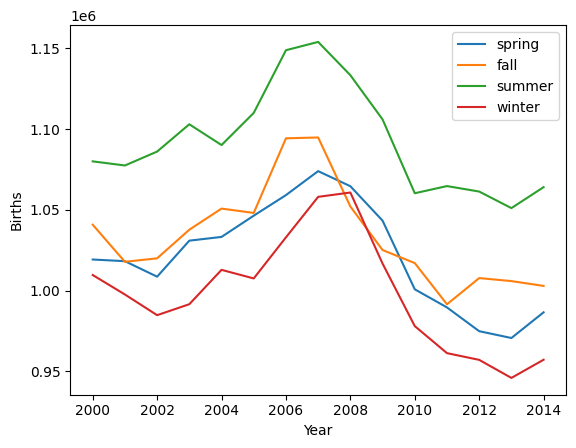

In [206]:
plt.plot(num_spring.index, num_spring.births)
plt.plot(num_spring.index, num_fall.births)
plt.plot(num_spring.index, num_summer.births)
plt.plot(num_spring.index, num_winter.births)
plt.xlabel('Year')
plt.ylabel('Births')
plt.legend(["spring",'fall','summer','winter'])

2. In class we found that the total number of births roughly correlated with the rise of the housing bubble and subsequent great recession.  We also found that people were generally superstitious, having fewer babies on Friday the 13th compared to other weekdays.  Does the level of superstition change with the health of the US economy?
**564 students**: find some actual public data on the health of the US economy and see if a particular metric tracks with the annual birth rate in the US.

So, I would find the number of babies per FY Q (3 terms prior (I think people decide to have kids)) and then if the economy is good the births should be high. That means I should plot the # of babies in FY-3 against the econ metric of choice (probably gdp per capita). 

Step 1) Put the baby birhts in to "quarters" instead of seasons (seasons already align with the fiscal quarters)

Step 2) Plot a shift of the data st [:-3] for fiscal Q and [3:] for babies. 

In [98]:
GDP_pC = pd.read_csv('FiscalQ_GDPpC.csv', names =['date','GDP'])
babies_by_season = pd.concat([num_winter,num_spring,num_summer,num_fall]).sort_values(by='year')
labels=round(len(babies_by_season[:-3])/4)*['winter','spring','summer','winter']

labels.append('spring')


Text(0.5, 0, 'GDP per Capita')

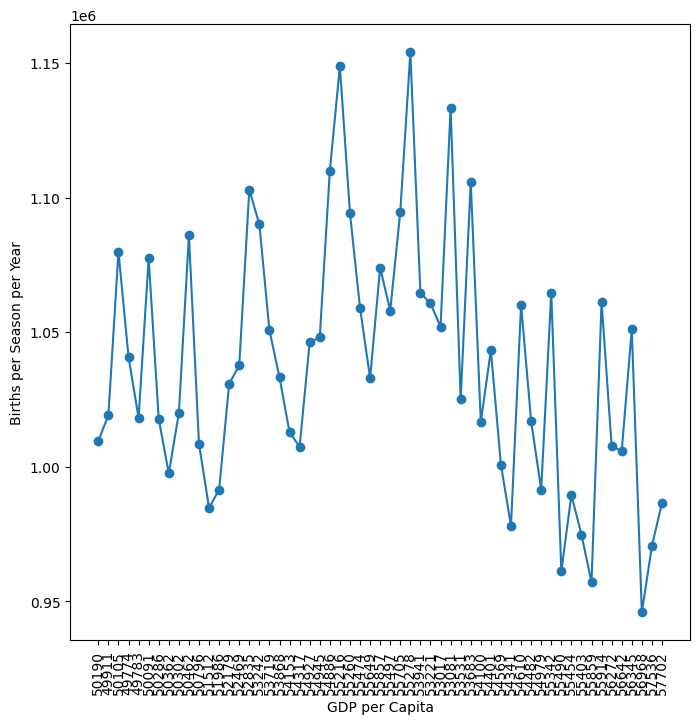

In [211]:
fig,ax = plt.subplots(figsize=(8,8))
ax.scatter(GDP_pC['GDP'][4:],babies_by_season['births'][:-3])
ax.plot(GDP_pC['GDP'][4:],babies_by_season['births'][:-3])
ax.tick_params("x", rotation=90)
plt.ylabel('Births per Season per Year')
plt.xlabel('GDP per Capita')
# for i, txt in enumerate(labels):
#     ax.annotate(txt,xy=(GDP_pC['GDP'][4+i],babies_by_season['births'].iloc[i]))

3. Download and parse the TMDB data.  Find an interesting feature in the data.  Be sure to describe clearly the feature you found, and include figures to back it up.

In [110]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

In [115]:
print(movies.columns)
print(credits.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')
Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')


We will find whichgenre of movies has on 'average/median' the best votes.

In [ ]:
avg_score = movies.groupby('original_language')['vote_average'].mean()

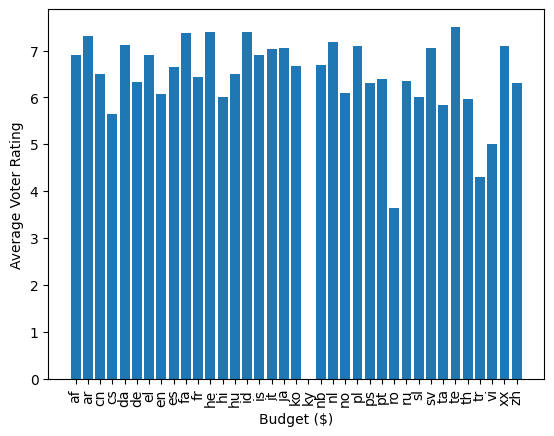

In [ ]:
fig,ax = plt.subplots()
ax.bar(avg_score.index,avg_score[:])
plt.xlabel('Original Language')
plt.ylabel('Average Voter Rating')
ax.tick_params("x", rotation=90)

There is no distinction between the original language of a film and the average voter rating. 

In [202]:
avg_budg = movies.groupby('original_language')['budget'].mean()

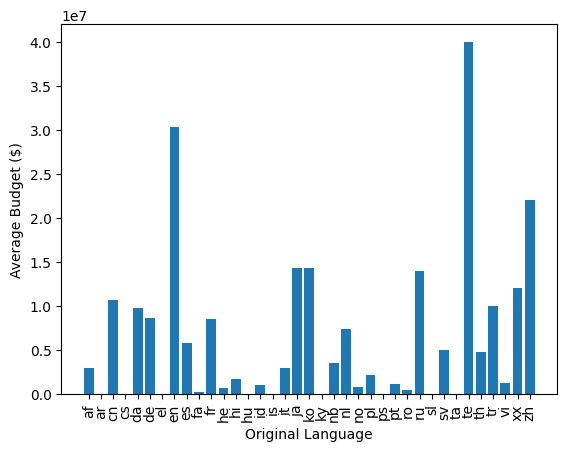

In [205]:
fig,ax = plt.subplots()
ax.bar(avg_score.index,avg_budg[:])
plt.xlabel('Original Language')
plt.ylabel('Average Budget ($)')
ax.tick_params("x", rotation=90)

There is however significant impacts on the original language and the budget of the film. Te is the highest languaged-budgeted film (I think it is Telugu?) and after English has the highest budgeted films. So despite budget not necessarily changing the popularity levels of films, English and Telugu films tend to invest more without much variation in ratings.